# Aging Interpolation (Leave-One-Epoch-Out)

> **Authors:** Davide Corso, Marco Soldani  
> **Context:** Analysis of Galvanostatic Electrochemical Impedance Spectroscopy (GEIS) data on Lithium-Ion batteries (LiCoO₂).
>
**Expected Result:** Exclude an **entire Epoch** (all 8 Nyquist plots at different temperatures) and predict it using the other 4 Epochs. This simulates a real-world scenario where the model interpolates the battery behavior at an unseen aging level.

---

### Difference with the other previos LOO notebook (1: LOO)

| | Leave-One-Out (NB1) | Leave-One-Epoch-Out (NB2) |
|---|---|---|
| **Excluded data** | 1 combination (~245 samples) | 1 full Epoch (~1960 samples) |
| **Training** | 39 combinations | 32 combinations (4 Epoch × 8 Temp) |
| **Challenge** | Interpolate a single plot from neighboring conditions | Interpolate an entire aging level |
| **Available information** | Same Epoch at other temperatures + same temperature at other Epochs | Only other Epochs, no data from the excluded Epoch |

# 1. Setup

In [2]:
import sys
assert sys.version_info >= (3, 5), "Python 3.5+ is required"

# --- STANDARD LIBRARIES ---
import warnings
import time

# --- SCIENTIFIC LIBRARIES ---
import numpy as np
import pandas as pd
import scipy.io

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- MACHINE LEARNING ---
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rc("axes", labelsize=13)
mpl.rc("xtick", labelsize=11)
mpl.rc("ytick", labelsize=11)
mpl.rc("legend", fontsize=10)
mpl.rc("figure", dpi=120)

# --- CONSTANTS ---
TEMP_COLORS = {
    20.0: "#1b9e77",
    22.5: "#d95f02",
    25.0: "#7570b3",
    27.5: "#e7298a",
    30.0: "#66a61e",
    35.0: "#e6ab02",
    40.0: "#a6761d",
    47.5: "#666666",
}

EPOCH_LABELS = {
    0: "Epoch 0 (Fresh)",
    1: "Epoch 1",
    2: "Epoch 2",
    3: "Epoch 3",
    4: "Epoch 4 (Aged)",
}

SOC_MARKERS = {
    0: "o",
    1: "s",
    2: "^",
    3: "D",
    4: "v",
}

TEMPS_SORTED = sorted(TEMP_COLORS.keys())
EPOCHS = list(EPOCH_LABELS.keys())

# --- ENVIRONMENT INFO ---
def print_environment_info():
    import sklearn

    print("Setup completed")
    print(
        f"Python {sys.version_info.major}.{sys.version_info.minor} | "
        f"NumPy {np.__version__} | "
        f"Pandas {pd.__version__} | "
        f"Scikit-learn {sklearn.__version__}"
    )


print_environment_info()

Setup completed
Python 3.12 | NumPy 2.0.1 | Pandas 2.3.3 | Scikit-learn 1.7.1


# 2. Data Loading

In [3]:
# --- LOAD DATASET ---
from pathlib import Path

file_path = Path("..") / "data" / "raw" / "GEIS.mat"
mat_data = scipy.io.loadmat(
    file_path,
    squeeze_me=True,
    struct_as_record=False
)

# --- TEMPERATURE MAPPING ---
TEMP_KEYS = {
    "GEIS_20": 20.0,
    "GEIS_22_5": 22.5,
    "GEIS_25": 25.0,
    "GEIS_27_5": 27.5,
    "GEIS_30": 30.0,
    "GEIS_35": 35.0,
    "GEIS_40": 40.0,
    "GEIS_47_5": 47.5,
}

# --- DATA EXTRACTION ---
records = []

for epoch in range(5):
    aging_struct = getattr(
        mat_data,
        f"Aging{epoch}",
        mat_data.get(f"Aging{epoch}")
    )

    for temp_key, temp_val in TEMP_KEYS.items():
        data = getattr(aging_struct, temp_key)

        for soc_idx, soc_data in enumerate(data):
            for row in soc_data:
                records.append({
                    "Epoch": epoch,
                    "Temperature": temp_val,
                    "SOC": soc_idx,
                    "Frequency": row[0],
                    "Z_real": row[1] * 1000,
                    "Z_imag": row[2] * 1000,
                })

df = pd.DataFrame(records)

# --- DATASET SUMMARY ---
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

n_combinations = df.groupby(["Epoch", "Temperature"]).ngroups

print(f"{n_combinations} Epoch × Temperature combinations")

Dataset: 9,805 rows × 6 columns
40 Epoch × Temperature combinations


# 3. EDA: Focus on Aging
> Let’s analyze how impedance changes across Epochs to understand the interpolation challenge.

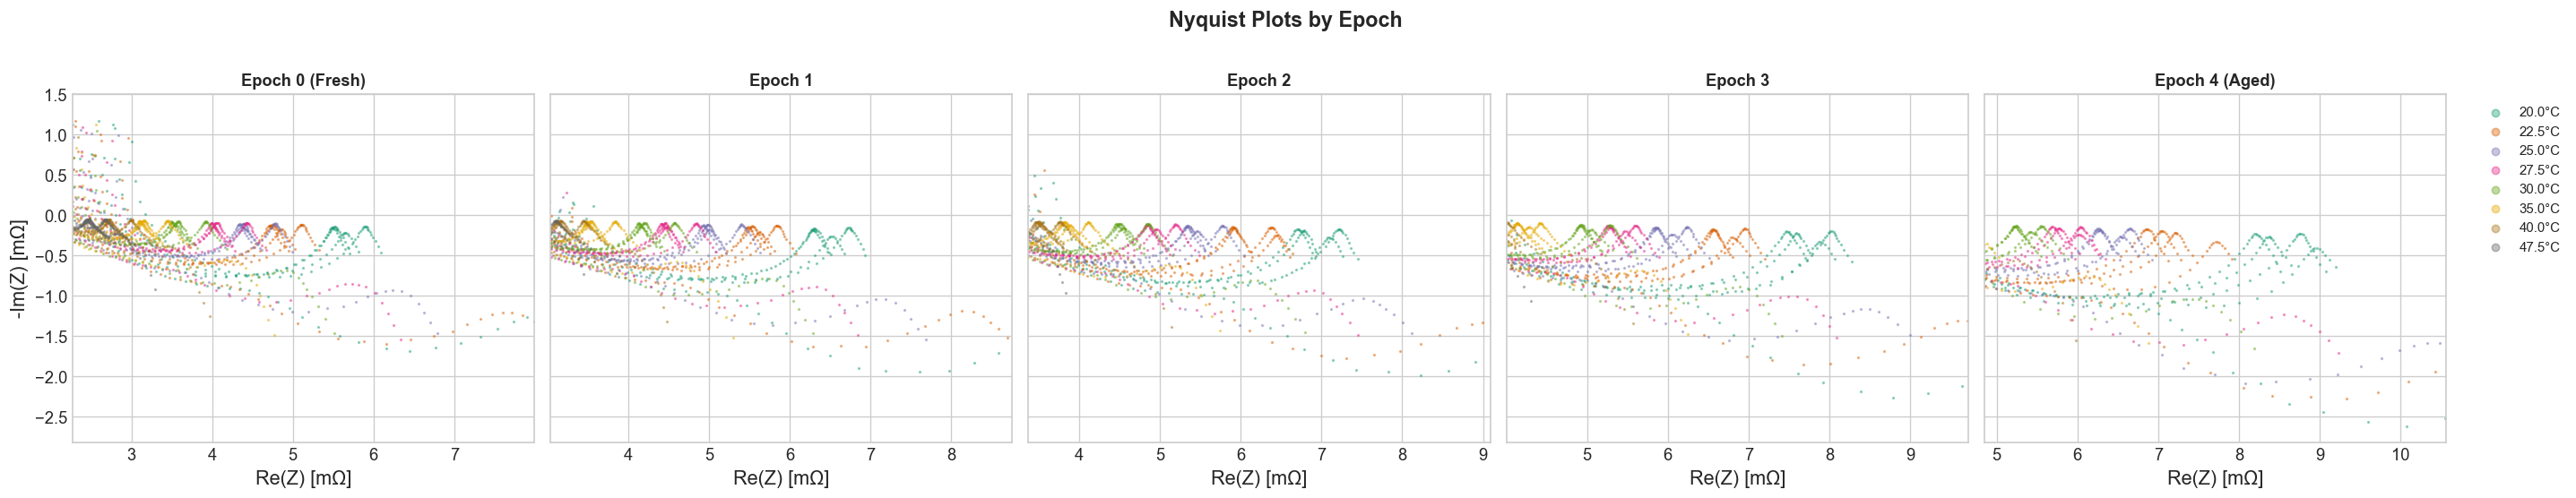

In [4]:
# --- NYQUIST PLOTS BY EPOCH (ALL TEMPERATURES OVERLAID) ---

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for epoch in range(5):
    ax = axes[epoch]
    subset = df[df["Epoch"] == epoch]

    for temp in TEMPS_SORTED:
        mask = subset["Temperature"] == temp

        ax.scatter(
            subset.loc[mask, "Z_real"],
            -subset.loc[mask, "Z_imag"],
            s=1,
            alpha=0.4,
            color=TEMP_COLORS[temp],
            label=f"{temp}°C",
        )

    ax.set_xlabel("Re(Z) [mΩ]")

    if epoch == 0:
        ax.set_ylabel("-Im(Z) [mΩ]")

    ax.set_title(
        EPOCH_LABELS[epoch],
        fontsize=11,
        fontweight="bold",
    )

    ax.set_aspect("equal", adjustable="datalim")

axes[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=5,
    fontsize=9,
)

fig.suptitle(
    "Nyquist Plots by Epoch",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

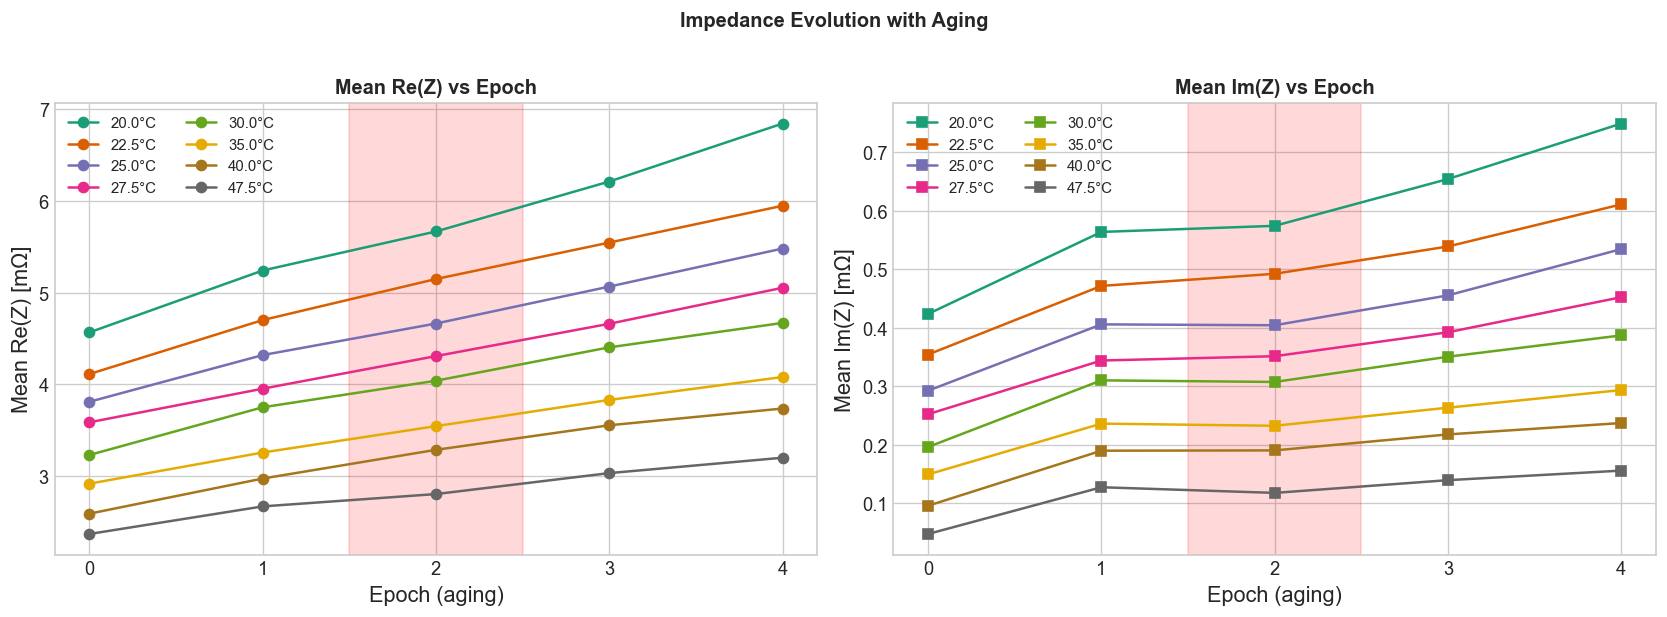

The red band highlights Epoch 2, which will be predicted.


In [5]:
# --- IMPEDANCE EVOLUTION WITH AGING ---
# Mean Re(Z) and Im(Z) per Epoch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for temp in TEMPS_SORTED:
    subset = df[df["Temperature"] == temp]

    means_r = subset.groupby("Epoch")["Z_real"].mean()
    means_i = subset.groupby("Epoch")["Z_imag"].mean()

    axes[0].plot(
        means_r.index,
        means_r.values,
        marker="o",
        color=TEMP_COLORS[temp],
        label=f"{temp}°C",
    )

    axes[1].plot(
        means_i.index,
        means_i.values,
        marker="s",
        color=TEMP_COLORS[temp],
        label=f"{temp}°C",
    )

for ax, title, ylabel in zip(
    axes,
    ["Mean Re(Z) vs Epoch", "Mean Im(Z) vs Epoch"],
    ["Mean Re(Z) [mΩ]", "Mean Im(Z) [mΩ]"],
):
    ax.set_xlabel("Epoch (aging)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(EPOCHS)
    ax.legend(fontsize=9, ncol=2)

    # --- HIGHLIGHT EPOCH 2 ---
    ax.axvspan(
        1.5,
        2.5,
        alpha=0.15,
        color="red",
        label="Epoch 2 (to predict)",
    )

fig.suptitle(
    "Impedance Evolution with Aging",
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

print("The red band highlights Epoch 2, which will be predicted.")

In [6]:
# --- HOW DIFFERENT IS EACH EPOCH FROM THE OTHERS? ---

print("=== MEAN DISTANCE BETWEEN EPOCHS (based on mean impedance) ===\n")

epoch_means = (
    df.groupby(["Epoch", "Temperature"])[["Z_real", "Z_imag"]]
    .mean()
    .reset_index()
)

for e_target in range(5):

    distances = []

    for e_other in range(5):
        if e_other == e_target:
            continue

        target = epoch_means[
            epoch_means["Epoch"] == e_target
        ][["Z_real", "Z_imag"]].values

        other = epoch_means[
            epoch_means["Epoch"] == e_other
        ][["Z_real", "Z_imag"]].values

        dist = np.mean(
            np.sqrt(
                np.sum((target - other) ** 2, axis=1)
            )
        )

        distances.append(dist)

    print(
        f"Epoch {e_target}: mean distance from others = {np.mean(distances):.4f} mΩ"
    )

=== MEAN DISTANCE BETWEEN EPOCHS (based on mean impedance) ===

Epoch 0: mean distance from others = 0.9778 mΩ
Epoch 1: mean distance from others = 0.6262 mΩ
Epoch 2: mean distance from others = 0.5444 mΩ
Epoch 3: mean distance from others = 0.6338 mΩ
Epoch 4: mean distance from others = 0.8905 mΩ
